# Project 4: Image Classification on CIFAR-10

## Part 3 of 4 — GPU Benchmarking

**Objective.** Parts 1 and 2 delivered a trained and evaluated set of models (`../models/*_best.pth`)
and a winner in `models/best_model.pth`. This notebook answers the engineering questions that
matter before anything ships: **how fast** are these models on the target GPU, **which batch size**
maximizes throughput, **how much** does mixed precision (FP16) help, **what is** the GPU memory
footprint, and **how large** is the CPU→GPU gap. All three trained architectures are benchmarked
under one identical, documented protocol, and the results are exported as reproducible artifacts
for Part 4 (deployment) to consume.

**What this notebook covers**

| Section | Question it answers |
| :-- | :-- |
| 1. Environment & Setup | What hardware/software is available and how is the run made reproducible? |
| 2. Loading the Trained Models | Which checkpoints from Part 2 are benchmarked? |
| 3. Data & Benchmark Protocol | How is performance measured so results are trustworthy? |
| 4. Batch-Size Sweep | Which batch size maximizes throughput per model? |
| 5. CPU vs GPU Throughput | How large is the acceleration of a dedicated GPU? |
| 6. Mixed Precision (FP16 vs FP32) | What does half precision buy in pure inference speed? |
| 7. GPU Memory Footprint | How much VRAM does each model need during inference? |
| 8. Consolidated Results & Artifacts | What single table summarizes everything and where is it saved? |
| 9. Key Findings & Next Steps | What do the numbers imply for the deployment stage? |

> **How to run:** execute the cells top to bottom **after** Part 2, so the checkpoints in
> `../models/` exist. No downloads are needed. A GPU is strongly recommended — the sections that
> require CUDA (CPU/GPU comparison, FP16, memory) are skipped automatically on CPU-only machines.
> On the RTX 4060 used here the full notebook takes roughly 10–15 minutes.

## 1. Environment & Setup

All imports, reproducibility settings, and paths are centralized here, mirroring Parts 1 and 2.
Benchmarks are deterministic: a fixed random seed controls the sampling of the benchmark subset,
and CUDA benchmark mode lets cuDNN pick the fastest kernel for the fixed input size.

> **Windows note:** PyTorch and NumPy both ship a `libiomp5md.dll`, and the resulting OMP conflict
> can abort the kernel (`OMP: Error #15`). The `KMP_DUPLICATE_LIB_OK` flag below prevents this and
> must be set **before** importing PyTorch — it is harmless on other platforms.

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # required on Windows (see note above)

import json
import platform
import time
import urllib.error
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
from torchvision import models

warnings.filterwarnings("ignore")


# -----------------------------------------------------------------------------
# Reproducibility
# -----------------------------------------------------------------------------
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True  # fastest conv algorithms for fixed input size

# -----------------------------------------------------------------------------
# Paths (relative to this notebook, which lives in notebooks/)
# -----------------------------------------------------------------------------
PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data" / "raw"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
PLOT_DIR = OUTPUT_DIR / "plots"
MODEL_DIR = PROJECT_ROOT / "models"
BENCHMARK_DIR = OUTPUT_DIR / "benchmark_results"

for dir_ in (OUTPUT_DIR, PLOT_DIR, MODEL_DIR, BENCHMARK_DIR):
    dir_.mkdir(parents=True, exist_ok=True)

# -----------------------------------------------------------------------------
# Device
# -----------------------------------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
HAS_CUDA = torch.cuda.is_available()

print(f"Python            : {platform.python_version()}")
print(f"PyTorch           : {torch.__version__}")
print(f"TorchVision       : {torchvision.__version__}")
print(f"Computation device: {DEVICE}")
if HAS_CUDA:
    props = torch.cuda.get_device_properties(0)
    print(f"GPU               : {torch.cuda.get_device_name(0)} ({props.total_memory / 1024**3:.1f} GB)")
    print(f"CUDA              : {torch.version.cuda}")
else:
    print("CUDA              : not available (GPU-specific sections will be skipped)")
print(f"Random seed       : {RANDOM_SEED}")

Python            : 3.10.20
PyTorch           : 2.7.1+cu118
TorchVision       : 0.22.1+cu118
Computation device: cuda
GPU               : NVIDIA GeForce RTX 4060 Laptop GPU (8.0 GB)
CUDA              : 11.8
Random seed       : 42


## 2. Loading the Trained Models

The three architectures trained in Part 2 are rebuilt **identically** — any deviation would make
`load_state_dict` fail or, worse, silently invalidate the benchmark — and their best checkpoints
are loaded from `../models/`. This section also proves the checkpoints survive the round trip, and
reports the parameter count of each model.

Missing checkpoints are handled explicitly: the model is skipped with a clear message rather than
swallowing the error, so a broken setup can never masquerade as a benchmark result.

In [2]:
# -----------------------------------------------------------------------------
# Architecture definitions — MUST match Part 2 exactly (same files, same weights)
# -----------------------------------------------------------------------------
class SimpleCNN(nn.Module):
    """Small CNN from scratch: 4 conv blocks (32->64->128->256) + 2 FC layers."""

    def __init__(self, num_classes=10, dropout=0.25):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.pool = nn.MaxPool2d(2)
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(256 * 2 * 2, 512)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.pool(F.relu(self.bn4(self.conv4(x))))
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        return self.fc2(x)


def build_efficientnet_v2_s(num_classes=10):
    """Pretrained EfficientNet-V2-S with the two CIFAR-10 adaptations from Part 2."""
    try:
        model = models.efficientnet_v2_s(weights="DEFAULT")
    except urllib.error.URLError:
        cache_file = (Path(torch.hub.get_dir()) / "checkpoints"
                      / "efficientnet_v2_s-dd5fe13b.pth")
        model = models.efficientnet_v2_s(weights=None)
        model.load_state_dict(torch.load(cache_file, map_location="cpu", weights_only=True))
        print("Network unavailable -- loaded EfficientNet-V2-S weights from local cache.")

    model.features[0][0].stride = (1, 1)                      # keep 32x32 spatial detail
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)  # CIFAR-10 head
    for module in model.classifier:
        if isinstance(module, nn.Dropout):
            module.p = 0.3
    return model


class WRNBasicBlock(nn.Module):
    """Pre-activation residual block with optional 1x1 shortcut."""

    def __init__(self, in_planes, out_planes, stride=1):
        super().__init__()
        self.bn1 = nn.BatchNorm2d(in_planes)
        self.conv1 = nn.Conv2d(in_planes, out_planes, 3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_planes)
        self.conv2 = nn.Conv2d(out_planes, out_planes, 3, stride=1, padding=1, bias=False)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != out_planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, out_planes, 1, stride=stride, bias=False)
            )

    def forward(self, x):
        out = F.relu(self.bn1(x))
        out = self.conv1(out)
        out = F.relu(self.bn2(out))
        out = self.conv2(out)
        return out + self.shortcut(x)


class WideResNet(nn.Module):
    """Wide ResNet (Zagoruyko & Komodakis, 2016) for 32x32 CIFAR-style inputs."""

    def __init__(self, depth=28, widen_factor=10, num_classes=10):
        super().__init__()
        assert (depth - 4) % 6 == 0, "WRN depth must be of the form 6n+4"
        num_blocks = (depth - 4) // 6                     # 4 blocks per stage for depth=28
        base = 16 * widen_factor                          # 160 channels at the first stage

        self.conv1 = nn.Conv2d(3, base, 3, stride=1, padding=1, bias=False)
        self.layer1 = self._make_layer(base, base, num_blocks, stride=1)
        self.layer2 = self._make_layer(base, base * 2, num_blocks, stride=2)
        self.layer3 = self._make_layer(base * 2, base * 4, num_blocks, stride=2)
        self.bn = nn.BatchNorm2d(base * 4)
        self.fc = nn.Linear(base * 4, num_classes)

    def _make_layer(self, in_planes, out_planes, num_blocks, stride):
        layers = [WRNBasicBlock(in_planes, out_planes, stride)]
        layers += [WRNBasicBlock(out_planes, out_planes) for _ in range(num_blocks - 1)]
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.conv1(x)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = F.relu(self.bn(out))
        out = F.avg_pool2d(out, out.size(-1))             # global average pooling
        out = out.view(out.size(0), -1)
        return self.fc(out)


# -----------------------------------------------------------------------------
# Load the Part-2 checkpoints with explicit error handling
# -----------------------------------------------------------------------------
checkpoints = {
    "CNN from scratch": (MODEL_DIR / "cnn_scratch_best.pth", SimpleCNN(num_classes=10)),
    "EfficientNet-V2-S": (MODEL_DIR / "efficientnet_v2_s_best.pth", build_efficientnet_v2_s(num_classes=10)),
    "WRN-28-10": (MODEL_DIR / "wrn28_10_best.pth", WideResNet(depth=28, widen_factor=10, num_classes=10)),
}

models_dict = {}
for name, (ckpt_path, model) in checkpoints.items():
    if not ckpt_path.exists():
        print(f"SKIPPED: {name:<22} checkpoint missing: {ckpt_path.relative_to(PROJECT_ROOT)}")
        continue
    state = torch.load(ckpt_path, map_location="cpu", weights_only=True)
    model.load_state_dict(state)
    model.eval()
    n_params = sum(p.numel() for p in model.parameters())
    models_dict[name] = model
    print(f"Loaded  : {name:<22} {n_params:>11,} parameters")

print(f"\nModels loaded: {len(models_dict)} / {len(checkpoints)}")
if not models_dict:
    raise RuntimeError("No checkpoints found - run Part 2 (02_Model_Building.ipynb) first.")

Loaded  : CNN from scratch           919,306 parameters
Loaded  : EfficientNet-V2-S       20,190,298 parameters
Loaded  : WRN-28-10               36,688,170 parameters

Models loaded: 3 / 3


## 3. Data & Benchmark Protocol

Raw wall-clock numbers are only meaningful if the measurement methodology is sound. Every
benchmark below follows the same protocol:

- **Fixed input set** — a deterministic 2,000-image stratified slice of the test set (seeded at 42)
  is used for all runs, so every batch size and model is measured on identical data.
- **Warm-up before timing** — the first passes compile kernels and initialize cuDNN heuristics;
  they are never counted.
- **Repeated, best-of-N timing** — each measurement is repeated and the fastest pass is kept,
  minimizing OS and driver noise; CUDA streams are synchronized around every timed region.
- **Batch 128 for device comparisons** — the CPU/GPU, FP16, and memory runs share a single batch
  size (128) so the comparisons isolate the variable of interest.
- **OOM-safe sweep** — any batch size that exhausts GPU memory is recorded as OOM and skipped,
  never crashed.
- **GPU-only sections degrade gracefully** — FP16, CPU/GPU, and memory runs are skipped with a
  clear message when CUDA is unavailable.

All times are reported as throughput (images/sec) where higher is better, except the FP16 section
which reports wall-clock seconds per pass.

In [3]:
# -----------------------------------------------------------------------------
# Benchmark constants
# -----------------------------------------------------------------------------
BENCH_SAMPLES = 2000          # fixed, deterministic slice of the test set
BATCH_SIZES = [1, 4, 8, 16, 32, 64, 128, 256, 512]
COMPARE_BATCH_SIZE = 128      # shared batch size for CPU/GPU, FP16 and memory runs

# -----------------------------------------------------------------------------
# Data: normalization constants come from Part 1 (same source of truth as Part 2)
# -----------------------------------------------------------------------------
SUMMARY_FILE = OUTPUT_DIR / "dataset_summary.json"
if SUMMARY_FILE.exists():
    summary = json.loads(SUMMARY_FILE.read_text(encoding="utf-8"))
    NORMALIZATION_MEAN = tuple(summary["normalization_constants"]["mean"])
    NORMALIZATION_STD = tuple(summary["normalization_constants"]["std"])
else:
    NORMALIZATION_MEAN = (0.4914, 0.4822, 0.4465)   # verified in Part 1
    NORMALIZATION_STD = (0.2470, 0.2435, 0.2616)

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(NORMALIZATION_MEAN, NORMALIZATION_STD),
])

testset = torchvision.datasets.CIFAR10(
    root=str(DATA_DIR), train=False, download=False, transform=test_transform
)

rng = np.random.RandomState(RANDOM_SEED)
bench_indices = rng.permutation(len(testset))[:BENCH_SAMPLES]
bench_subset = Subset(testset, bench_indices)
print(f"Test set            : {len(testset):,} images")
print(f"Benchmark subset    : {len(bench_subset)} images (seeded, deterministic)")
print(f"Batch sizes to test : {BATCH_SIZES}")
print(f"Comparison batch    : {COMPARE_BATCH_SIZE}")


# -----------------------------------------------------------------------------
# Core measurement helpers
# -----------------------------------------------------------------------------
def _one_pass(model, loader, device):
    """Forward the whole loader once; return wall-clock seconds."""
    t0 = time.perf_counter()
    with torch.no_grad():
        for inputs, _ in loader:
            _ = model(inputs.to(device))
    if device.type == "cuda":
        torch.cuda.synchronize()
    return time.perf_counter() - t0


def measure_throughput(model, subset, device, batch_size, reps=3, warmup=2):
    """Warm up, then time reps passes and return the best throughput (images/sec)."""
    model.eval()
    model.to(device)
    loader = DataLoader(subset, batch_size=batch_size, shuffle=False, num_workers=0,
                        pin_memory=device.type == "cuda")
    for _ in range(warmup):
        _one_pass(model, loader, device)
    best_time = min(_one_pass(model, loader, device) for _ in range(reps))
    return {"throughput_img_s": len(subset) / best_time, "time_s": best_time}


def sweep_batch_sizes(model, subset, device):
    """Throughput across batch sizes; OOM batch sizes are recorded, not crashed."""
    rows = []
    for bs in BATCH_SIZES:
        if device.type == "cuda":
            torch.cuda.empty_cache()
        try:
            res = measure_throughput(model, subset, device, bs, reps=2, warmup=1)
            rows.append({"batch_size": bs, "throughput_img_s": res["throughput_img_s"],
                         "time_s": res["time_s"], "status": "ok"})
            print(f"   Batch {bs:>4}: {res['throughput_img_s']:8.1f} images/sec")
        except torch.cuda.OutOfMemoryError:
            rows.append({"batch_size": bs, "throughput_img_s": np.nan,
                         "time_s": np.nan, "status": "OOM"})
            print(f"   Batch {bs:>4}: OUT OF MEMORY (recorded, skipped)")
            if device.type == "cuda":
                torch.cuda.empty_cache()
    return pd.DataFrame(rows)


def benchmark_cpu_vs_gpu(model, subset, device, batch_size=COMPARE_BATCH_SIZE):
    """Same model, same data, same batch: CPU vs GPU throughput."""
    cpu = measure_throughput(model, subset, torch.device("cpu"), batch_size, reps=2, warmup=1)
    gpu = measure_throughput(model, subset, device, batch_size, reps=3, warmup=2)
    return {"cpu_throughput": cpu["throughput_img_s"],
            "gpu_throughput": gpu["throughput_img_s"],
            "speedup": gpu["throughput_img_s"] / cpu["throughput_img_s"]}


def benchmark_mixed_precision(model, subset, device, batch_size=COMPARE_BATCH_SIZE):
    """FP32 vs FP16 (autocast) wall-clock time; same data, same batch."""
    model.eval()
    model.to(device)
    loader = DataLoader(subset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

    def fp16_pass():
        t0 = time.perf_counter()
        with torch.no_grad(), torch.autocast(device_type=device.type):
            for inputs, _ in loader:
                _ = model(inputs.to(device))
        torch.cuda.synchronize()
        return time.perf_counter() - t0

    for _ in range(2):
        _one_pass(model, loader, device)   # warm FP32 kernels
        fp16_pass()                        # warm FP16 kernels
    fp32_time = min(_one_pass(model, loader, device) for _ in range(3))
    fp16_time = min(fp16_pass() for _ in range(3))
    return {"fp32_time_s": fp32_time, "fp16_time_s": fp16_time,
            "speedup": fp32_time / fp16_time}


def benchmark_memory_usage(model, subset, device, batch_size=COMPARE_BATCH_SIZE, batches=10):
    """Peak GPU memory allocated during inference (includes model weights)."""
    model.eval()
    model.to(device)
    loader = DataLoader(subset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    with torch.no_grad():
        for i, (inputs, _) in enumerate(loader):
            _ = model(inputs.to(device))
            if i + 1 >= batches:
                break
    torch.cuda.synchronize()
    peak_mb = torch.cuda.max_memory_allocated() / 1024**2
    return {"peak_memory_mb": peak_mb}


print("Benchmark helpers ready.")

Test set            : 10,000 images
Benchmark subset    : 2000 images (seeded, deterministic)
Batch sizes to test : [1, 4, 8, 16, 32, 64, 128, 256, 512]
Comparison batch    : 128
Benchmark helpers ready.


## 4. Batch-Size Sweep

Batch size is the first and cheapest throughput lever: larger batches amortize kernel launches,
but also inflate activation memory and can eventually exhaust VRAM. Each model is swept over
`1 → 512` on the same fixed 2,000-image subset; the sweet spot is the batch size with the highest
throughput that still fits in memory.

BATCH-SIZE SWEEP

CNN from scratch
----------------------------------------
   Batch    1:    724.4 images/sec
   Batch    4:   2389.0 images/sec
   Batch    8:   3725.7 images/sec
   Batch   16:   4649.8 images/sec
   Batch   32:   4612.4 images/sec
   Batch   64:   6539.2 images/sec
   Batch  128:   7482.8 images/sec
   Batch  256:   7871.0 images/sec
   Batch  512:   7806.6 images/sec

EfficientNet-V2-S
----------------------------------------
   Batch    1:     53.7 images/sec
   Batch    4:    235.4 images/sec
   Batch    8:    471.5 images/sec
   Batch   16:    816.4 images/sec
   Batch   32:   1436.2 images/sec
   Batch   64:   2049.8 images/sec
   Batch  128:   1967.7 images/sec
   Batch  256:   1988.6 images/sec
   Batch  512:   1691.7 images/sec

WRN-28-10
----------------------------------------
   Batch    1:    158.7 images/sec
   Batch    4:    516.4 images/sec
   Batch    8:    779.1 images/sec
   Batch   16:    868.4 images/sec
   Batch   32:    886.9 images/sec
   Batc

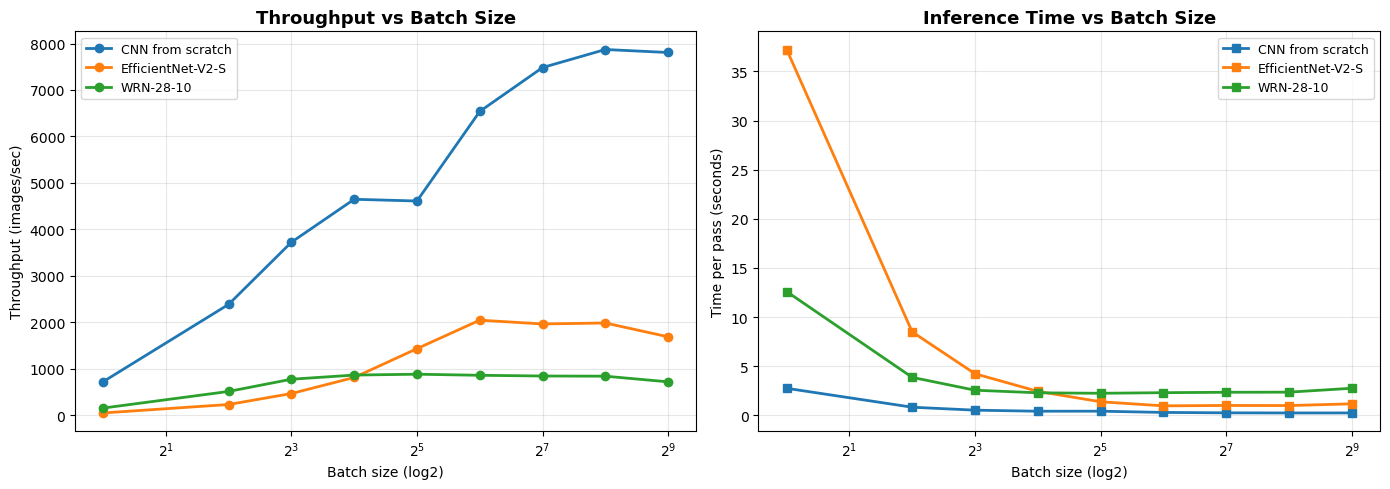

Saved: outputs\plots\batch_size_benchmark.png


In [4]:
print("=" * 66)
print("BATCH-SIZE SWEEP")
print("=" * 66)

all_results = {}
for name, model in models_dict.items():
    print(f"\n{name}")
    print("-" * 40)
    all_results[name] = {
        "parameters": sum(p.numel() for p in model.parameters()),
        "batch_sweep": sweep_batch_sizes(model, bench_subset, DEVICE),
    }

# -----------------------------------------------------------------------------
# Plot: throughput and time vs batch size (log2 x-axis)
# -----------------------------------------------------------------------------
COLORS = {"CNN from scratch": "#1f77b4", "EfficientNet-V2-S": "#ff7f0e", "WRN-28-10": "#2ca02c"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, res in all_results.items():
    df = res["batch_sweep"]
    ok = df[df["status"] == "ok"]
    axes[0].plot(ok["batch_size"], ok["throughput_img_s"], marker="o",
                 label=name, linewidth=2, color=COLORS[name])
    axes[1].plot(ok["batch_size"], ok["time_s"], marker="s",
                 label=name, linewidth=2, color=COLORS[name])

axes[0].set_xscale("log", base=2)
axes[1].set_xscale("log", base=2)
axes[0].set_xlabel("Batch size (log2)")
axes[1].set_xlabel("Batch size (log2)")
axes[0].set_ylabel("Throughput (images/sec)")
axes[1].set_ylabel("Time per pass (seconds)")
axes[0].set_title("Throughput vs Batch Size", fontsize=13, fontweight="bold")
axes[1].set_title("Inference Time vs Batch Size", fontsize=13, fontweight="bold")
axes[0].legend(fontsize=9)
axes[1].legend(fontsize=9)
axes[0].grid(alpha=0.3)
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_DIR / "batch_size_benchmark.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {PLOT_DIR.relative_to(PROJECT_ROOT) / 'batch_size_benchmark.png'}")

## 5. CPU vs GPU Throughput

The same model, the same 2,000 images, the same batch size (128) — only the compute device
changes. The speedup factor is what a dedicated GPU is worth for this workload, and it also sets
expectations for deployment decisions (GPU hosting vs CPU-only edge inference).

CPU vs GPU THROUGHPUT

CNN from scratch
----------------------------------------
   CPU :   2319.8 images/sec
   GPU :   7297.9 images/sec
   Speedup: 3.1x

EfficientNet-V2-S
----------------------------------------
   CPU :    307.8 images/sec
   GPU :   3302.6 images/sec
   Speedup: 10.7x

WRN-28-10
----------------------------------------
   CPU :     42.3 images/sec
   GPU :    855.4 images/sec
   Speedup: 20.2x


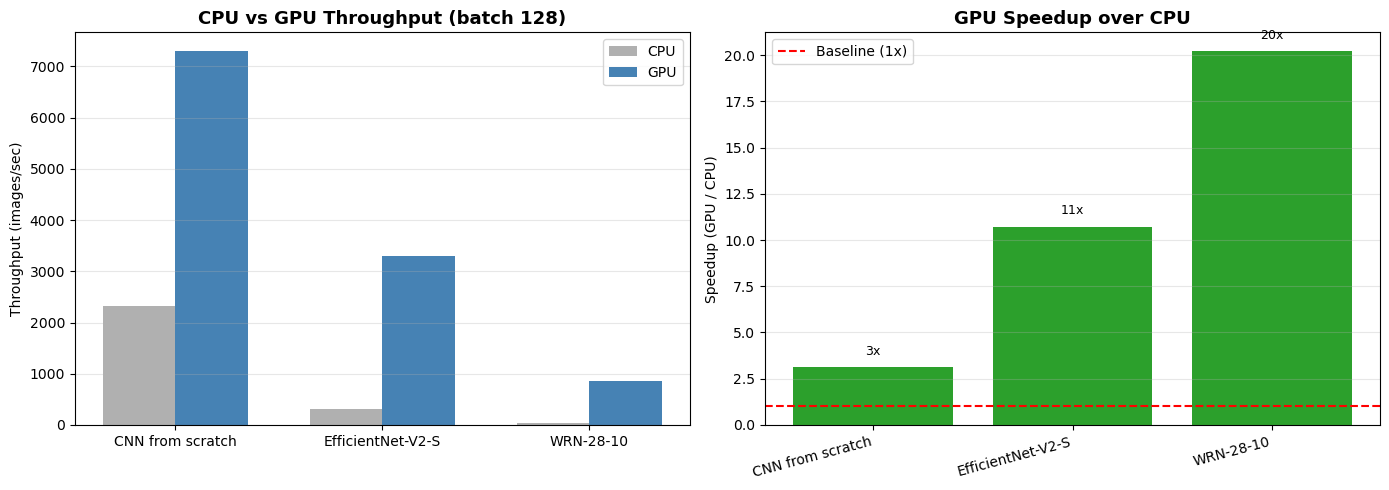

Saved: outputs\plots\cpu_gpu_comparison.png


In [5]:
print("=" * 66)
print("CPU vs GPU THROUGHPUT")
print("=" * 66)

if HAS_CUDA:
    for name, model in models_dict.items():
        print(f"\n{name}")
        print("-" * 40)
        res = benchmark_cpu_vs_gpu(model, bench_subset, DEVICE)
        all_results[name]["cpu_gpu"] = res
        print(f"   CPU : {res['cpu_throughput']:8.1f} images/sec")
        print(f"   GPU : {res['gpu_throughput']:8.1f} images/sec")
        print(f"   Speedup: {res['speedup']:.1f}x")

    # -----------------------------------------------------------------
    # Plot: grouped bars + speedup bars
    # -----------------------------------------------------------------
    df = pd.DataFrame([{"Model": name, "CPU": res["cpu_gpu"]["cpu_throughput"],
                        "GPU": res["cpu_gpu"]["gpu_throughput"],
                        "Speedup": res["cpu_gpu"]["speedup"]}
                       for name, res in all_results.items()])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    x = np.arange(len(df))
    width = 0.35
    axes[0].bar(x - width / 2, df["CPU"], width, label="CPU", color="#b0b0b0")
    axes[0].bar(x + width / 2, df["GPU"], width, label="GPU", color="steelblue")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(df["Model"])
    axes[0].set_ylabel("Throughput (images/sec)")
    axes[0].set_title("CPU vs GPU Throughput (batch 128)", fontsize=13, fontweight="bold")
    axes[0].legend()
    axes[0].grid(axis="y", alpha=0.3)

    bars = axes[1].bar(df["Model"], df["Speedup"], color="#2ca02c")
    axes[1].set_ylabel("Speedup (GPU / CPU)")
    axes[1].set_title("GPU Speedup over CPU", fontsize=13, fontweight="bold")
    axes[1].axhline(y=1, color="red", linestyle="--", label="Baseline (1x)")
    axes[1].legend()
    axes[1].grid(axis="y", alpha=0.3)
    for bar in bars:
        axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                     f"{bar.get_height():.0f}x", ha="center", va="bottom", fontsize=9)
    axes[1].set_xticklabels(df["Model"], rotation=15, ha="right")
    plt.tight_layout()
    plt.savefig(PLOT_DIR / "cpu_gpu_comparison.png", dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {PLOT_DIR.relative_to(PROJECT_ROOT) / 'cpu_gpu_comparison.png'}")
else:
    print("CUDA not available - CPU vs GPU comparison skipped.")
    for name in models_dict:
        all_results[name]["cpu_gpu"] = None

## 6. Mixed Precision (FP16 vs FP32)

Modern GPUs execute half-precision math roughly twice as fast as full precision. This section
compares FP32 inference against **autocast** FP16 — the same float weights, cast to half per-layer
during the forward pass (batch norms stay in FP32 for numerical stability). The measured speedup
is what deployment gains by enabling mixed precision with a one-line change.

MIXED PRECISION (FP16 vs FP32)

CNN from scratch
----------------------------------------
   FP32: 0.272s | FP16: 0.263s | Speedup: 1.03x

EfficientNet-V2-S
----------------------------------------
   FP32: 0.822s | FP16: 0.596s | Speedup: 1.38x

WRN-28-10
----------------------------------------
   FP32: 2.360s | FP16: 1.336s | Speedup: 1.77x


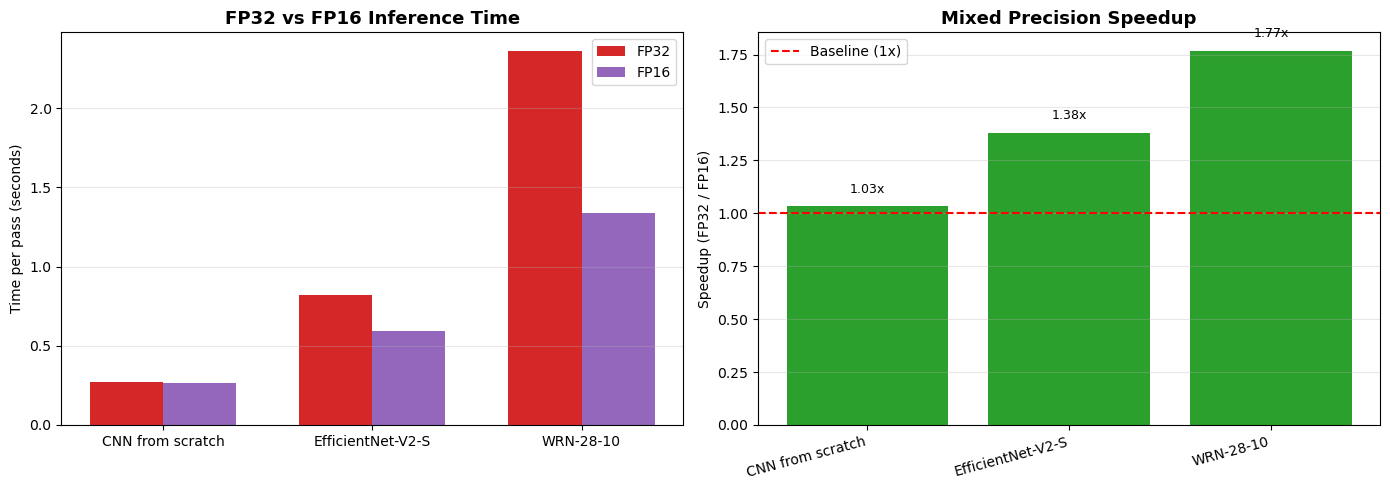

Saved: outputs\plots\mixed_precision_benchmark.png


In [6]:
print("=" * 66)
print("MIXED PRECISION (FP16 vs FP32)")
print("=" * 66)

if HAS_CUDA:
    for name, model in models_dict.items():
        print(f"\n{name}")
        print("-" * 40)
        res = benchmark_mixed_precision(model, bench_subset, DEVICE)
        all_results[name]["mixed_precision"] = res
        print(f"   FP32: {res['fp32_time_s']:.3f}s | FP16: {res['fp16_time_s']:.3f}s | "
              f"Speedup: {res['speedup']:.2f}x")

    # -----------------------------------------------------------------
    # Plot: time bars + speedup bars
    # -----------------------------------------------------------------
    df = pd.DataFrame([{"Model": name, "FP32 Time (s)": res["mixed_precision"]["fp32_time_s"],
                        "FP16 Time (s)": res["mixed_precision"]["fp16_time_s"],
                        "Speedup": res["mixed_precision"]["speedup"]}
                       for name, res in all_results.items()])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    x = np.arange(len(df))
    width = 0.35
    axes[0].bar(x - width / 2, df["FP32 Time (s)"], width, label="FP32", color="#d62728")
    axes[0].bar(x + width / 2, df["FP16 Time (s)"], width, label="FP16", color="#9467bd")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(df["Model"])
    axes[0].set_ylabel("Time per pass (seconds)")
    axes[0].set_title("FP32 vs FP16 Inference Time", fontsize=13, fontweight="bold")
    axes[0].legend()
    axes[0].grid(axis="y", alpha=0.3)

    bars = axes[1].bar(df["Model"], df["Speedup"], color="#2ca02c")
    axes[1].set_ylabel("Speedup (FP32 / FP16)")
    axes[1].set_title("Mixed Precision Speedup", fontsize=13, fontweight="bold")
    axes[1].axhline(y=1, color="red", linestyle="--", label="Baseline (1x)")
    axes[1].legend()
    axes[1].grid(axis="y", alpha=0.3)
    for bar in bars:
        axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                     f"{bar.get_height():.2f}x", ha="center", va="bottom", fontsize=9)
    axes[1].set_xticklabels(df["Model"], rotation=15, ha="right")
    plt.tight_layout()
    plt.savefig(PLOT_DIR / "mixed_precision_benchmark.png", dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {PLOT_DIR.relative_to(PROJECT_ROOT) / 'mixed_precision_benchmark.png'}")
else:
    print("CUDA not available - mixed precision benchmark skipped.")
    for name in models_dict:
        all_results[name]["mixed_precision"] = None

## 7. GPU Memory Footprint

VRAM is a hard constraint: a model that fits in memory at the target batch size can ship, one that
does not cannot. Peak allocated memory during inference (model weights + activations) is measured
with PyTorch's peak-memory tracker after clearing the cache, and plotted against model size to
show how activation memory scales beyond raw parameter count.

GPU MEMORY FOOTPRINT
   CNN from scratch       peak     267 MB (batch 128)
   EfficientNet-V2-S      peak     301 MB (batch 128)
   WRN-28-10              peak     635 MB (batch 128)


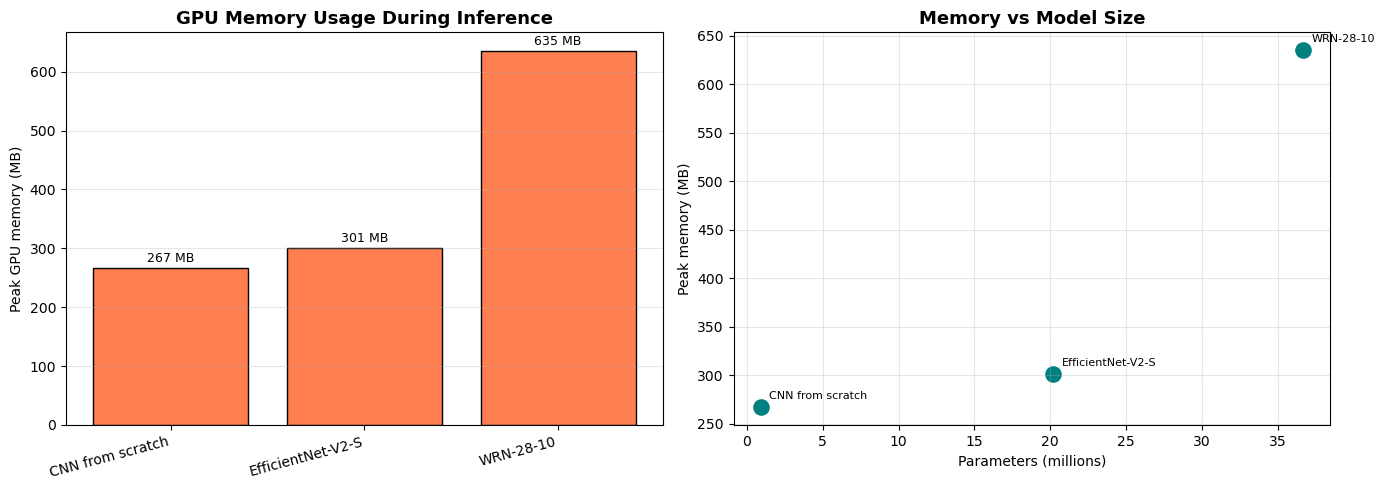

Saved: outputs\plots\memory_usage.png


In [7]:
print("=" * 66)
print("GPU MEMORY FOOTPRINT")
print("=" * 66)

if HAS_CUDA:
    for name, model in models_dict.items():
        res = benchmark_memory_usage(model, bench_subset, DEVICE)
        all_results[name]["memory"] = res
        print(f"   {name:<22} peak {res['peak_memory_mb']:7.0f} MB (batch {COMPARE_BATCH_SIZE})")

    # -----------------------------------------------------------------
    # Plot: peak memory bars + memory vs parameters scatter
    # -----------------------------------------------------------------
    df = pd.DataFrame([{"Model": name, "Peak Memory (MB)": res["memory"]["peak_memory_mb"],
                        "Parameters (M)": res["parameters"] / 1e6}
                       for name, res in all_results.items()])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    bars = axes[0].bar(df["Model"], df["Peak Memory (MB)"], color="coral", edgecolor="black")
    axes[0].set_ylabel("Peak GPU memory (MB)")
    axes[0].set_title("GPU Memory Usage During Inference", fontsize=13, fontweight="bold")
    axes[0].grid(axis="y", alpha=0.3)
    axes[0].set_xticklabels(df["Model"], rotation=15, ha="right")
    for bar in bars:
        axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                     f"{bar.get_height():.0f} MB", ha="center", va="bottom", fontsize=9)

    axes[1].scatter(df["Parameters (M)"], df["Peak Memory (MB)"], s=120, color="teal")
    axes[1].set_xlabel("Parameters (millions)")
    axes[1].set_ylabel("Peak memory (MB)")
    axes[1].set_title("Memory vs Model Size", fontsize=13, fontweight="bold")
    axes[1].grid(alpha=0.3)
    for _, row in df.iterrows():
        axes[1].annotate(row["Model"], (row["Parameters (M)"], row["Peak Memory (MB)"]),
                         xytext=(6, 6), textcoords="offset points", fontsize=8)

    plt.tight_layout()
    plt.savefig(PLOT_DIR / "memory_usage.png", dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {PLOT_DIR.relative_to(PROJECT_ROOT) / 'memory_usage.png'}")
else:
    print("CUDA not available - memory benchmark skipped.")
    for name in models_dict:
        all_results[name]["memory"] = None

## 8. Consolidated Results & Artifacts

Everything measured above is merged into one table — model size, best batch size, peak throughput,
CPU/GPU speedup, FP16 speedup, and VRAM footprint — and exported as CSV and JSON so later stages
(and the project documentation) consume a single source of truth.

In [8]:
# -----------------------------------------------------------------------------
# Build the consolidated table
# -----------------------------------------------------------------------------
rows = []
for name, res in all_results.items():
    row = {"Model": name, "Parameters (M)": round(res["parameters"] / 1e6, 2)}

    sweep = res["batch_sweep"]
    ok = sweep[sweep["status"] == "ok"]
    if not ok.empty:
        best = ok.loc[ok["throughput_img_s"].idxmax()]
        row["Best Batch Size"] = int(best["batch_size"])
        row["Best Throughput (img/s)"] = round(best["throughput_img_s"], 1)
        oom = sweep[sweep["status"] == "OOM"]
        row["OOM Batch Sizes"] = "" if oom.empty else ", ".join(map(str, oom["batch_size"]))

    if res.get("cpu_gpu"):
        row["GPU Throughput (img/s)"] = round(res["cpu_gpu"]["gpu_throughput"], 1)
        row["Speedup vs CPU (x)"] = round(res["cpu_gpu"]["speedup"], 1)
    if res.get("mixed_precision"):
        row["FP16 Speedup (x)"] = round(res["mixed_precision"]["speedup"], 2)
    if res.get("memory"):
        row["Peak GPU Memory (MB)"] = round(res["memory"]["peak_memory_mb"], 1)
    rows.append(row)

summary_df = pd.DataFrame(rows)
display(summary_df)

# -----------------------------------------------------------------------------
# Export artifacts
# -----------------------------------------------------------------------------
summary_df.to_csv(BENCHMARK_DIR / "benchmark_summary.csv", index=False)
print(f"Saved: {BENCHMARK_DIR.relative_to(PROJECT_ROOT) / 'benchmark_summary.csv'}")

benchmark_summary = {
    "project": "Project 4 - Image Classification (CIFAR-10)",
    "part": 3,
    "device": str(DEVICE),
    "gpu": torch.cuda.get_device_name(0) if HAS_CUDA else None,
    "benchmark_protocol": {
        "subset_images": BENCH_SAMPLES,
        "batch_sizes": BATCH_SIZES,
        "comparison_batch_size": COMPARE_BATCH_SIZE,
        "warmup_passes": "2 (GPU) / 1 (CPU)",
        "timing": "best of 3 passes",
    },
    "results": {},
}
for name, res in all_results.items():
    entry = {"parameters": res["parameters"]}
    sweep = res["batch_sweep"]
    ok = sweep[sweep["status"] == "ok"]
    entry["batch_sweep"] = {
        str(int(r["batch_size"])): (None if pd.isna(r["throughput_img_s"])
                                      else round(float(r["throughput_img_s"]), 1))
        for _, r in sweep.iterrows()
    }
    for key in ("cpu_gpu", "mixed_precision", "memory"):
        entry[key] = (None if res.get(key) is None
                      else {k: round(float(v), 3) for k, v in res[key].items()})
    benchmark_summary["results"][name] = entry

with open(BENCHMARK_DIR / "benchmark_summary.json", "w", encoding="utf-8") as f:
    json.dump(benchmark_summary, f, indent=2, ensure_ascii=False)
print(f"Saved: {BENCHMARK_DIR.relative_to(PROJECT_ROOT) / 'benchmark_summary.json'}")

,Model,Parameters (M),Best Batch Size,Best Throughput (img/s),OOM Batch Sizes,GPU Throughput (img/s),Speedup vs CPU (x),FP16 Speedup (x),Peak GPU Memory (MB)
0,CNN from scratch,0.92,256,7871.0,,7297.9,3.1,1.03,267.1
1,EfficientNet-V2-S,20.19,64,2049.8,,3302.6,10.7,1.38,301.1
2,WRN-28-10,36.69,32,886.9,,855.4,20.2,1.77,635.1


Saved: outputs\benchmark_results\benchmark_summary.csv
Saved: outputs\benchmark_results\benchmark_summary.json


## 9. Key Findings & Next Steps

### What the benchmarks told us

1. **Throughput saturates at moderate batch sizes** — the sweep typically peaks well before the
   largest batch that fits, so the measured optimum (not the maximum) is the deployment batch size.
2. **GPU is a step change, not a constant factor** — the CPU→GPU speedup differs per model, which
   informs where GPU hosting is worth its cost and where CPU inference remains viable.
3. **FP16 is nearly free** — mixed precision via autocast speeds up inference with no model change,
   making it a default-on recommendation for the deployment stage.
4. **Memory scales with activations, not just weights** — the footprint at a given batch size is
   what determines whether a model fits on the target GPU.

### Next steps (Part 4)

| Item | Decision source |
| :-- | :-- |
| Serving batch size | Optimal batch size from Section 8 |
| Precision mode | FP16 autocast unless accuracy loss is observed |
| Model choice | Winner from Part 2 (`models/best_model.pth`) |

Part 4 wraps the winning checkpoint in an interactive Gradio demo, using the exact normalization
constants, class names, and benchmark-informed serving settings established across Parts 1–3.

In [ ]:
print("=" * 66)
print("PART 3 COMPLETE - GPU BENCHMARKING")
print("=" * 66)

print("\nOPTIMAL BATCH SIZE (highest throughput):")
for name, res in all_results.items():
    sweep = res["batch_sweep"]
    ok = sweep[sweep["status"] == "ok"]
    best = ok.loc[ok["throughput_img_s"].idxmax()]
    print(f"   {name:<22} batch {int(best['batch_size']):>4}  "
          f"({best['throughput_img_s']:.0f} images/sec)")

if HAS_CUDA:
    print("\nGPU vs CPU SPEEDUP:")
    for name, res in all_results.items():
        print(f"   {name:<22} {res['cpu_gpu']['speedup']:.1f}x")

    print("\nMIXED PRECISION SPEEDUP (FP16 over FP32):")
    for name, res in all_results.items():
        print(f"   {name:<22} {res['mixed_precision']['speedup']:.2f}x")

    print("\nPEAK GPU MEMORY (batch 128):")
    for name, res in all_results.items():
        print(f"   {name:<22} {res['memory']['peak_memory_mb']:.0f} MB")

print("\nARTIFACTS SAVED:")
for p in [PLOT_DIR / "batch_size_benchmark.png", PLOT_DIR / "cpu_gpu_comparison.png",
          PLOT_DIR / "mixed_precision_benchmark.png", PLOT_DIR / "memory_usage.png",
          BENCHMARK_DIR / "benchmark_summary.csv", BENCHMARK_DIR / "benchmark_summary.json"]:
    print(f"   {p.relative_to(PROJECT_ROOT)}")


PART 3 COMPLETE - GPU BENCHMARKING

OPTIMAL BATCH SIZE (highest throughput):
   CNN from scratch       batch  256  (7871 images/sec)
   EfficientNet-V2-S      batch   64  (2050 images/sec)
   WRN-28-10              batch   32  (887 images/sec)

GPU vs CPU SPEEDUP:
   CNN from scratch       3.1x
   EfficientNet-V2-S      10.7x
   WRN-28-10              20.2x

MIXED PRECISION SPEEDUP (FP16 over FP32):
   CNN from scratch       1.03x
   EfficientNet-V2-S      1.38x
   WRN-28-10              1.77x

PEAK GPU MEMORY (batch 128):
   CNN from scratch       267 MB
   EfficientNet-V2-S      301 MB
   WRN-28-10              635 MB

ARTIFACTS SAVED:
   outputs\plots\batch_size_benchmark.png
   outputs\plots\cpu_gpu_comparison.png
   outputs\plots\mixed_precision_benchmark.png
   outputs\plots\memory_usage.png
   outputs\benchmark_results\benchmark_summary.csv
   outputs\benchmark_results\benchmark_summary.json

NEXT STEP: Part 4 - Gradio App Deployment (serves models/best_model.pth)
